# AG-HYPOPT · Trial 21

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803. Then trial_20 (sw 0.922, h_f 3.899, h_s 3.615, cap 0.203) 0.0821 (essentially tied with trial_05 0.0822), trial_09 0.0839, trial_18 0.0844, trial_16 0.0850, trial_11 0.0859, trial_17 0.0859, trial_06 0.0861, trial_15 0.0865, trial_19 0.0874, trial_08 0.0876, trial_12 0.0882, trial_13 0.0888, trial_14 0.0904, trial_10 0.0922. All 0 diverged, gamma finite. trial_07 remains a sharp interior optimum; trials 08-20 have not beaten it. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_21'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (20/5 trials)
ID |     ei | params
 1 | 3.8839 | {"gamma_rel_cap": 0.20022633733184375, "h_f_scale": 4.0, "h_s_scale": 3.604718891641892, "sigma_weight": 0.8340338275086131}
 2 | 3.5750 | {"gamma_rel_cap": 0.2660295670267344, "h_f_scale": 4.0, "h_s_scale": 3.579936326988331, "sigma_weight": 0.9285121996572236}
 3 | 3.8713 | {"gamma_rel_cap": 0.15691133973938487, "h_f_scale": 4.0, "h_s_scale": 3.6178635406937967, "sigma_weight": 0.9222238330560042}
 4 | 3.8325 | {"gamma_rel_cap": 0.14391523145756918, "h_f_scale": 4.0, "h_s_scale": 3.6214945298935524, "sigma_weight": 0.44334717604809726}
 5 | 3.3031 | {"gamma_rel_cap": 0.1805210360805873, "h_f_scale": 3.896378524549808, "h_s_scale": 3.6648889565912817, "sigma_weight": 0.7940409251650695}
 6 | 3.8067 | {"gamma_rel_cap": 0.09631698348830592, "h_f_scale": 4.0, "h_s_scale": 3.61211784966939, "sigma_weight": 0.5039638379977127}
 7 | 3.9586 | {"gamma_rel_cap": 0.2093019600801925, "h_f_scale": 3.95944089758495, "h_s_scale": 3.59

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is the optimum but trial_20 (0.0821) showed that a higher sigma weight (0.922) with flat kernels is the next-best design. Candidate 3 keeps exactly that high sigma weight and flat kernels but lowers the gamma cap toward the good band.

Candidate 3 (ei 3.8713) has sw 0.922 (as in trial_20), h_f 4.0, h_s 3.618 (as in trial_20) and a gamma cap 0.157, between trial_20's 0.203 and trial_07's 0.107. It is the closest in-region draw to the two best trials simultaneously and tests whether the high-sw design improves as the cap moves toward the optimum band.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # candidate 3: sigma_weight 0.922, h_f_scale 4.0, h_s_scale 3.618, gamma_rel_cap 0.157 (trial_20 region, smaller cap)


chosen: {'gamma_rel_cap': 0.15691133973938487, 'h_f_scale': 4.0, 'h_s_scale': 3.6178635406937967, 'sigma_weight': 0.9222238330560042}
Running  1nW Trans05 ... 

μ 9.39 -> 5.96 | γ 8.5 -> 4.58 | NLL 0.26


Running  1nW Trans20 ... 

μ 17.32 -> 26.89 | γ 8.5 -> 5.40 | NLL 0.67


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 67.28 | γ 14.1 -> 14.10 | NLL 0.71


Running 3nW Trans100 ... 

μ 175.71 -> 99.05 | γ 14.1 -> 13.77 | NLL 0.70



Total: 7.7 min


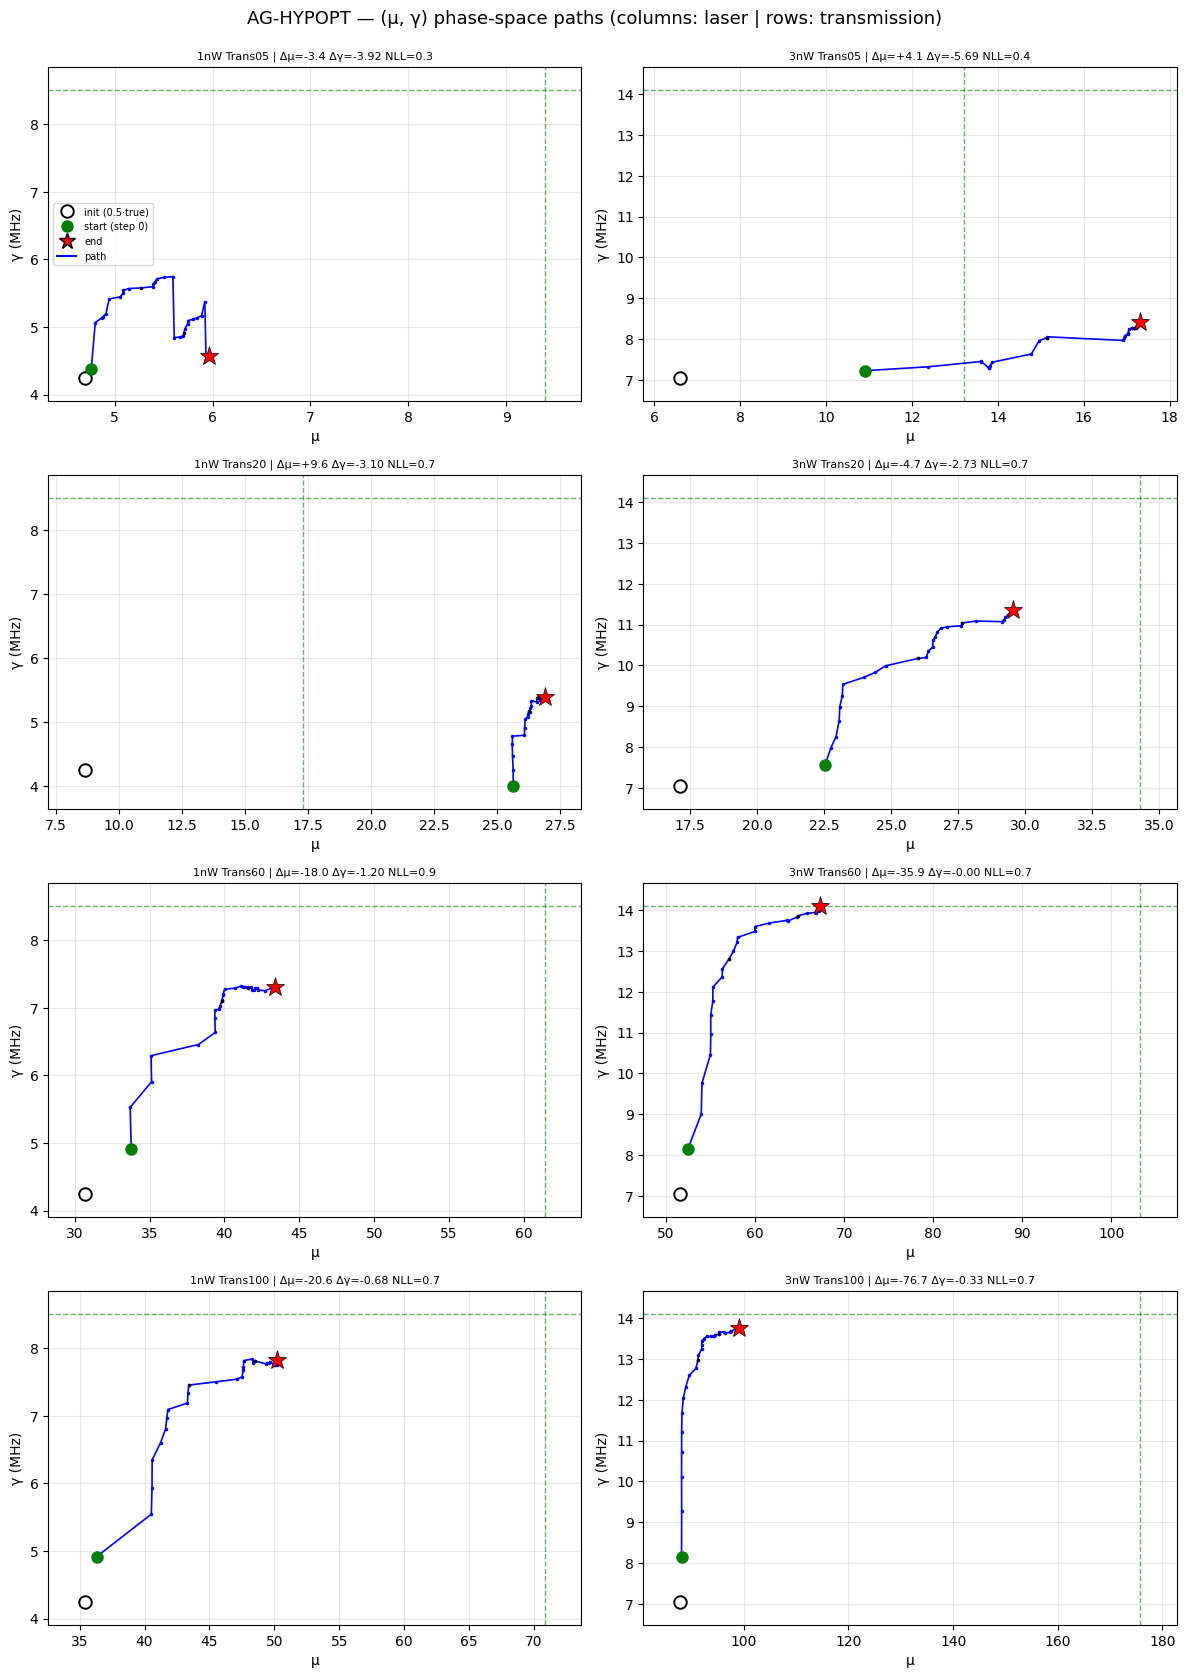

trial finished in 7.7 min
objective = 0.0852 ± 0.0220
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.96   -36.5 |     8.50    4.58   -46.2
1nW Trans20       17.32   26.89   +55.3 |     8.50    5.40   -36.5
1nW Trans60       61.37   43.38   -29.3 |     8.50    7.30   -14.1
1nW Trans100       70.82   50.21   -29.1 |     8.50    7.82    -8.0
3nW Trans05       13.20   17.31   +31.1 |    14.10    8.41   -40.4
3nW Trans20       34.28   29.55   -13.8 |    14.10   11.37   -19.4
3nW Trans60      103.20   67.28   -34.8 |    14.10   14.10    -0.0
3nW Trans100      175.71   99.05   -43.6 |    14.10   13.77    -2.3

weighted objective (T-graded, cap=1.0) = 0.0852 | diverged cells: 0
μ: RMSE 31.737 (rel 36.0%, bias -18.207) | γ: RMSE 2.892 (rel 26.8%, bias -2.207)


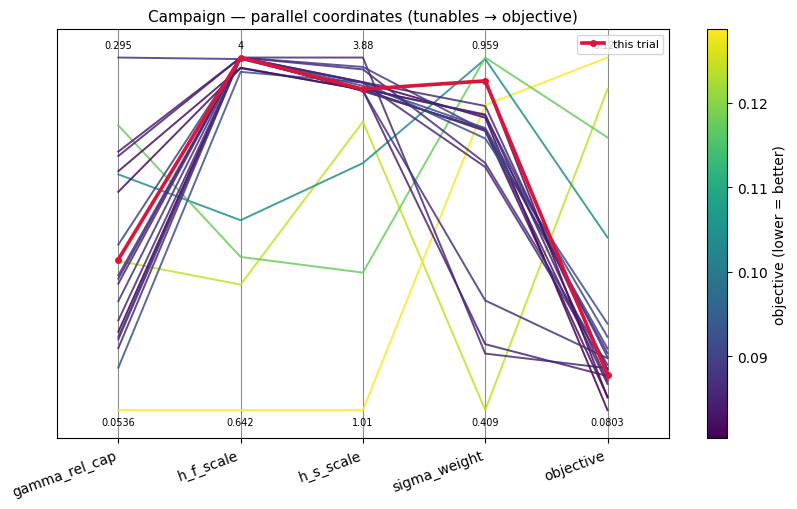

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 21 (sw 0.922, h_f 4.0, h_s 3.618, cap 0.157) ran to completion in 7.7 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0852 +/- 0.0220 - worse than trial_07 (0.0803) and than trial_20 (0.0821), which shared the same kernels and sigma weight but a larger cap.

mu rel-RMSE 36.0% (worse than trial_20's 34.6%): same shape - high-T undershoot (3nW Trans100 -43.6%, 3nW Trans60 -34.8%, 1nW Trans60 -29.3%, 1nW Trans100 -29.1%), low-T overshoot (1nW Trans20 +55.3%, 3nW Trans05 +31.1%); bias -18.21.

gamma rel-RMSE 26.8% (worse than trial_07's 22.3%, about equal to trial_20's 26.9%): low T under-estimated (1nW Trans05 -46.2%, 3nW Trans05 -40.4%, 1nW Trans20 -36.5%), high T near truth (-0.0%, -2.3%).

The candidate held trial_20's high sigma weight and flat kernels but reduced the gamma cap (0.203 -> 0.157), and the objective worsened. In the high-sw design a cap near 0.20 is better, whereas for trial_07's moderate sw a smaller cap (~0.11) was best - so the optimal gamma cap depends on the sigma weight rather than being a single fixed value.

**Summary:** Trial 21 (sw=0.922, h_f=4.0, h_s=3.618, cap=0.157) finished in 7.7 min with 0 diverged cells and gamma finite, objective 0.0852 +/- 0.0220 - worse than trial_20 (0.0821) and trial_07 (mu rel-RMSE 36.0%, gamma rel-RMSE 26.8%).
**Key insight:** Lowering the cap from 0.203 (trial_20) to 0.157 with the same high sigma weight worsened the objective (0.0852 vs 0.0821), so the optimal gamma cap depends on the sigma weight rather than being a single fixed value.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 21 (sw=0.922, h_f=4.0, h_s=3.618, cap=0.157): objective 0.0852 +/- 0.0220 - worse than trial_20 and trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 36.0%, gamma rel-RMSE 26.8%).'
KEY_INSIGHT = 'Lowering the cap from 0.203 (trial_20) to 0.157 with the same high sigma weight worsened the objective (0.0852 vs 0.0821), so the optimal gamma cap depends on the sigma weight rather than being a single fixed value.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_21 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_22.ipynb. Open it and follow its cells from the top.
